# E-Commerce A/B Test Analysis
## Landing Page Conversion Experiment

A rigorous statistical analysis of an A/B test where an e-commerce company tested a **new landing page design** against their existing page to determine its impact on **purchase conversion rate**.

This notebook covers:
1. Data overview & sanity checks
2. Descriptive statistics with confidence intervals
3. Frequentist hypothesis testing (Z-test)
4. Statistical power analysis
5. Effect size & revenue impact
6. Segmented analysis with Bonferroni correction
7. Bayesian Beta-Binomial analysis
8. Final recommendation

---
**Dataset:** 300,000 users | 30-day experiment | Control vs Treatment groups


## Setup

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import NormalIndPower

%matplotlib inline
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.3,
    "font.size": 11, "axes.titlesize": 14, "axes.labelsize": 12,
})
warnings.filterwarnings("ignore")

# Directories
FIGURES_DIR = Path("figures")
RESULTS_DIR = Path("results")
DATA_DIR = Path("data")
FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# Business assumptions
MONTHLY_VISITORS = 500_000
AVG_ORDER_VALUE = 75.0
SIGNIFICANCE_LEVEL = 0.05
PRACTICAL_THRESHOLD = 0.005

COLORS = {"control": "#3498db", "treatment": "#e74c3c", "neutral": "#95a5a6"}
print("✅ Libraries loaded successfully")


✅ Libraries loaded successfully


---
## Section 1: Data Overview & Sanity Checks


In [2]:
# Load dataset
csv_files = list(DATA_DIR.glob("*.csv"))
if csv_files:
    print(f"Loading dataset: {csv_files[0].name}")
    df = pd.read_csv(csv_files[0])
    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"])
else:
    print("Generating synthetic data...")
    rng = np.random.default_rng(42)
    n = 300_000
    groups = ["control"] * (n // 2) + ["treatment"] * (n // 2)
    devices = rng.choice(["desktop", "mobile", "tablet"], size=n, p=[0.45, 0.40, 0.15])
    device_mod = np.where(devices == "desktop", 1.1, np.where(devices == "mobile", 0.85, 1.0))
    days = rng.integers(0, 30, size=n)
    hours = rng.integers(0, 24, size=n)
    timestamps = pd.to_datetime("2024-01-01") + pd.to_timedelta(days, unit="D")
    user_type = rng.choice(["new", "returning"], size=n, p=[0.6, 0.4])
    user_mod = np.where(user_type == "returning", 1.15, 1.0)
    base_rates = np.where(np.array(groups) == "control", 0.120, 0.123)
    adjusted = np.clip(base_rates * device_mod * user_mod, 0, 1)
    converted = rng.binomial(1, adjusted)
    df = pd.DataFrame({"user_id": range(1, n + 1), "group": groups, "converted": converted,
                       "device": devices, "timestamp": timestamps, "hour": hours, "user_type": user_type})

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(10)


Loading dataset: ab_test_data.csv


Dataset shape: 300,000 rows × 7 columns


   user_id    group  converted   device  timestamp  hour  user_type
0        1  control          1   mobile 2024-01-24     6        new
1        2  control          1  desktop 2024-01-15     9        new
2        3  control          0   tablet 2024-01-05     6  returning
3        4  control          0   mobile 2024-01-13    11  returning
4        5  control          0  desktop 2024-01-30    21  returning
5        6  control          0   tablet 2024-01-23    17        new
6        7  control          0   mobile 2024-01-03    14        new
7        8  control          0   mobile 2024-01-23     6  returning
8        9  control          0  desktop 2024-01-26    13        new
9       10  control          0   mobile 2024-01-23     0  returning

In [3]:
# Sanity checks
n_duplicates = df["user_id"].duplicated().sum()
group_counts = df["group"].value_counts()
n_control = group_counts.get("control", 0)
n_treatment = group_counts.get("treatment", 0)
n_total = n_control + n_treatment

chi2_stat, srm_pvalue = stats.chisquare([n_control, n_treatment])

print(f"Duplicate users: {n_duplicates}")
print(f"\nGroup sizes:")
print(f"  Control:    {n_control:>8,} ({n_control/n_total:.1%})")
print(f"  Treatment:  {n_treatment:>8,} ({n_treatment/n_total:.1%})")
print(f"\nSample Ratio Mismatch test: chi2={chi2_stat:.2f}, p={srm_pvalue:.4f}")
print("  ✅ No SRM detected" if srm_pvalue >= 0.01 else "  ⚠ SRM DETECTED")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"Conversion values: {sorted(df['converted'].unique())}")


Duplicate users: 0

Group sizes:
  Control:     150,000 (50.0%)
  Treatment:   150,000 (50.0%)

Sample Ratio Mismatch test: chi2=0.00, p=1.0000
  ✅ No SRM detected

Missing values: 0
Conversion values: [np.int64(0), np.int64(1)]


---
## Section 2: Descriptive Statistics


In [4]:
control = df[df["group"] == "control"]
treatment = df[df["group"] == "treatment"]

cr_control = control["converted"].mean()
cr_treatment = treatment["converted"].mean()
absolute_diff = cr_treatment - cr_control
relative_lift = (cr_treatment - cr_control) / cr_control * 100

print(f"Conversion Rates:")
print(f"  Control:             {cr_control:.4f} ({cr_control:.2%})")
print(f"  Treatment:           {cr_treatment:.4f} ({cr_treatment:.2%})")
print(f"  Absolute difference: {absolute_diff:+.4f} ({absolute_diff:+.2%})")
print(f"  Relative lift:       {relative_lift:+.2f}%")


Conversion Rates:
  Control:             0.1260 (12.60%)
  Treatment:           0.1270 (12.70%)
  Absolute difference: +0.0010 (+0.10%)
  Relative lift:       +0.81%


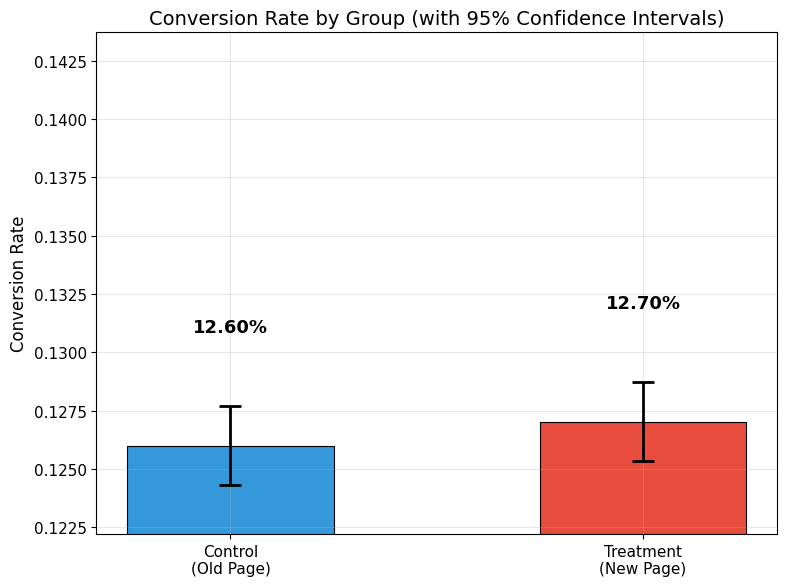

In [5]:
# Wilson confidence intervals
def wilson_ci(successes, n, confidence=0.95):
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    p_hat = successes / n
    denom = 1 + z**2 / n
    center = (p_hat + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p_hat * (1 - p_hat) + z**2 / (4 * n)) / n) / denom
    return (center - margin, center + margin)

rates = [cr_control, cr_treatment]
groups_labels = ["Control\n(Old Page)", "Treatment\n(New Page)"]
ci_control = wilson_ci(control["converted"].sum(), len(control))
ci_treatment = wilson_ci(treatment["converted"].sum(), len(treatment))
ci_tops = [ci_control[1], ci_treatment[1]]

errors = [
    [rates[0] - ci_control[0], rates[1] - ci_treatment[0]],
    [ci_control[1] - rates[0], ci_treatment[1] - rates[1]],
]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(groups_labels, rates, color=[COLORS["control"], COLORS["treatment"]],
              width=0.5, edgecolor="black", linewidth=0.8)
ax.errorbar(groups_labels, rates, yerr=errors, fmt="none", color="black",
            capsize=8, capthick=2, linewidth=2)
ax.set_ylabel("Conversion Rate")
ax.set_title("Conversion Rate by Group (with 95% Confidence Intervals)")

y_label_offset = 0.003  # fixed gap above error bar cap
for bar, rate, ci_top in zip(bars, rates, ci_tops):
    ax.text(bar.get_x() + bar.get_width() / 2, ci_top + y_label_offset,
            f"{rate:.2%}", ha="center", va="bottom", fontweight="bold", fontsize=13)

ax.set_ylim(bottom=min(rates) * 0.97, top=max(ci_tops) + y_label_offset * 5)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "conversion_rates_ci.png", dpi=150)
plt.show()


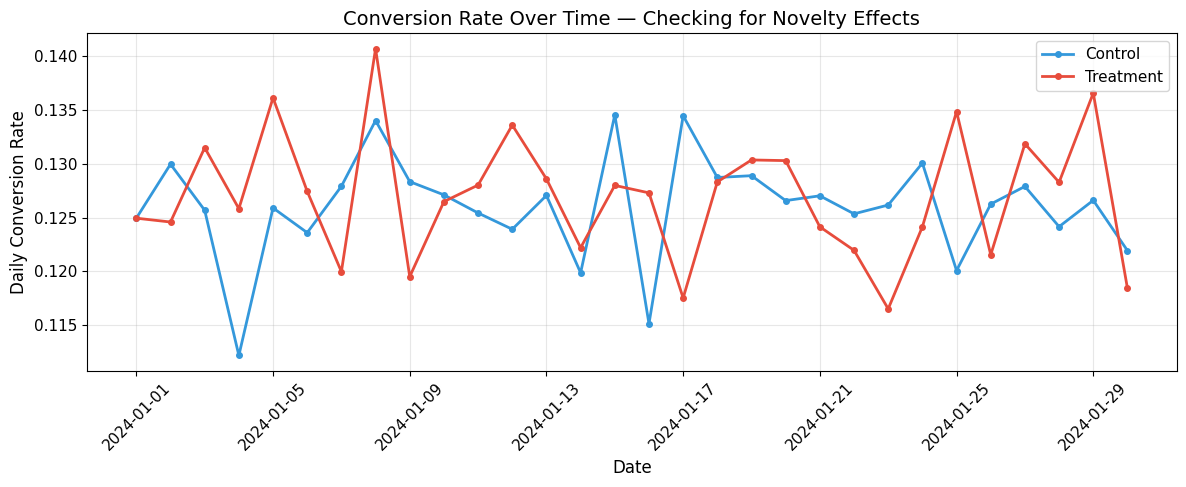

In [6]:
# Conversion over time (novelty effect check)
fig, ax = plt.subplots(figsize=(12, 5))
daily = df.groupby([pd.Grouper(key="timestamp", freq="D"), "group"])["converted"].mean().reset_index()
for group, color in [("control", COLORS["control"]), ("treatment", COLORS["treatment"])]:
    gd = daily[daily["group"] == group]
    ax.plot(gd["timestamp"], gd["converted"], marker="o", markersize=4,
            color=color, label=group.title(), linewidth=2)
ax.set_xlabel("Date")
ax.set_ylabel("Daily Conversion Rate")
ax.set_title("Conversion Rate Over Time — Checking for Novelty Effects")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "conversion_over_time.png", dpi=150)
plt.show()


---
## Section 3: Frequentist Hypothesis Testing

**Hypotheses:**
- H₀: p_treatment = p_control (no difference)
- H₁: p_treatment ≠ p_control (two-sided)


In [7]:
n_c, n_t = len(control), len(treatment)
x_c, x_t = control["converted"].sum(), treatment["converted"].sum()
p_c, p_t = x_c / n_c, x_t / n_t

# Pooled proportion under H0
p_pool = (x_c + x_t) / (n_c + n_t)
se = np.sqrt(p_pool * (1 - p_pool) * (1/n_c + 1/n_t))
z_stat = (p_t - p_c) / se
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

# 95% CI for the difference
se_diff = np.sqrt(p_c * (1 - p_c) / n_c + p_t * (1 - p_t) / n_t)
z_crit = stats.norm.ppf(1 - SIGNIFICANCE_LEVEL / 2)
ci_lower = (p_t - p_c) - z_crit * se_diff
ci_upper = (p_t - p_c) + z_crit * se_diff

# Scipy validation
z_scipy, p_scipy = proportions_ztest([x_t, x_c], [n_t, n_c], alternative="two-sided")

print(f"Pooled proportion (H₀):     {p_pool:.6f}")
print(f"Standard error:              {se:.6f}")
print(f"Z-statistic (manual):        {z_stat:.4f}")
print(f"P-value (manual):            {p_value:.6f}")
print(f"Z-statistic (scipy):         {z_scipy:.4f}")
print(f"P-value (scipy):             {p_scipy:.6f}")
print(f"95% CI for difference:       [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"                             [{ci_lower:.2%}, {ci_upper:.2%}]")
print()
if p_value < SIGNIFICANCE_LEVEL:
    print(f"✅ REJECT H₀ at α = {SIGNIFICANCE_LEVEL} — statistically significant")
else:
    print(f"❌ FAIL TO REJECT H₀ at α = {SIGNIFICANCE_LEVEL} — not significant")


Pooled proportion (H₀):     0.126503
Standard error:              0.001214
Z-statistic (manual):        0.8403
P-value (manual):            0.400724
Z-statistic (scipy):         0.8403
P-value (scipy):             0.400724
95% CI for difference:       [-0.0014, 0.0034]
                             [-0.14%, 0.34%]

❌ FAIL TO REJECT H₀ at α = 0.05 — not significant


---
## Section 4: Statistical Power Analysis


Effect size (Cohen's h):      0.0031 (negligible)
Achieved statistical power:   13.40%
Required n/group (80% power): 1,667,238
Actual n/group:               150,000

⚠ UNDERPOWERED — 87% chance of missing a real effect


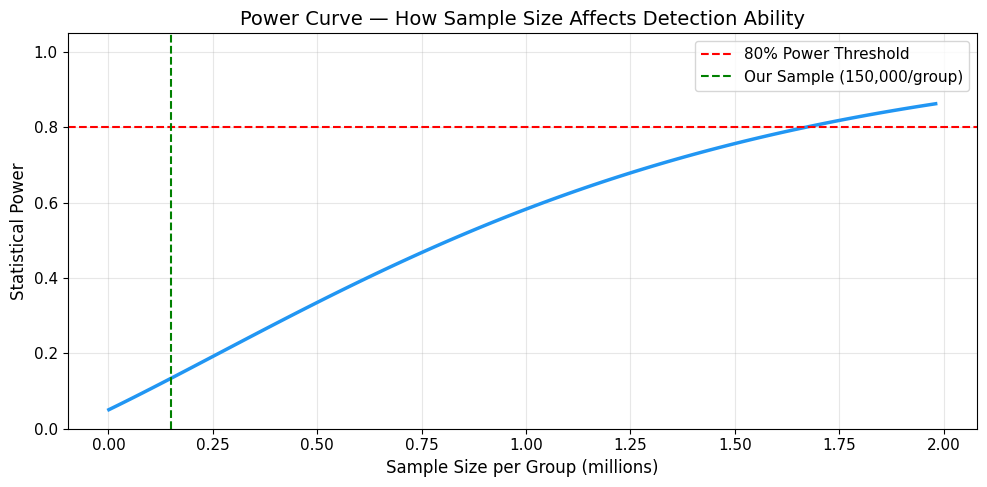

In [8]:
cohens_h = 2 * np.arcsin(np.sqrt(p_t)) - 2 * np.arcsin(np.sqrt(p_c))
interp = "negligible" if abs(cohens_h) < 0.2 else ("small" if abs(cohens_h) < 0.5 else ("medium" if abs(cohens_h) < 0.8 else "large"))

power_analyzer = NormalIndPower()
avg_n = (n_c + n_t) / 2
achieved_power = power_analyzer.power(
    effect_size=abs(cohens_h) if abs(cohens_h) > 0.001 else 0.01,
    nobs1=avg_n, alpha=SIGNIFICANCE_LEVEL, ratio=1.0, alternative="two-sided"
)
required_n = power_analyzer.solve_power(
    effect_size=abs(cohens_h) if abs(cohens_h) > 0.001 else 0.01,
    power=0.80, alpha=SIGNIFICANCE_LEVEL, ratio=1.0, alternative="two-sided"
)

print(f"Effect size (Cohen's h):      {cohens_h:.4f} ({interp})")
print(f"Achieved statistical power:   {achieved_power:.2%}")
print(f"Required n/group (80% power): {int(required_n):,}")
print(f"Actual n/group:               {int(avg_n):,}")
print()
if achieved_power >= 0.80:
    print("✅ Adequate power — results are trustworthy")
else:
    print(f"⚠ UNDERPOWERED — {1-achieved_power:.0%} chance of missing a real effect")

# Power curve
fig, ax = plt.subplots(figsize=(10, 5))
sample_sizes = np.arange(1000, 2_000_001, 20000)
powers = [power_analyzer.power(
    effect_size=abs(cohens_h) if abs(cohens_h) > 0.001 else 0.01,
    nobs1=n, alpha=SIGNIFICANCE_LEVEL, ratio=1.0, alternative="two-sided")
    for n in sample_sizes]
ax.plot(sample_sizes / 1e6, powers, linewidth=2.5, color="#2196F3")
ax.axhline(y=0.80, color="red", linestyle="--", linewidth=1.5, label="80% Power Threshold")
ax.axvline(x=avg_n / 1e6, color="green", linestyle="--", linewidth=1.5, label=f"Our Sample ({int(avg_n):,}/group)")
ax.set_xlabel("Sample Size per Group (millions)")
ax.set_ylabel("Statistical Power")
ax.set_title("Power Curve — How Sample Size Affects Detection Ability")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "power_analysis.png", dpi=150)
plt.show()


---
## Section 5: Effect Size & Revenue Impact


In [9]:
diff = p_t - p_c
additional_monthly = MONTHLY_VISITORS * diff
monthly_revenue = additional_monthly * AVG_ORDER_VALUE
annual_revenue = monthly_revenue * 12

print(f"Assumptions:")
print(f"  Monthly visitors:  {MONTHLY_VISITORS:,}")
print(f"  Avg order value:   ${AVG_ORDER_VALUE:.2f}")
print(f"  Min meaningful lift: {PRACTICAL_THRESHOLD:.1%}")
print()
print(f"Additional conversions/month: {additional_monthly:+,.0f}")
print(f"Monthly revenue impact:       ${monthly_revenue:+,.2f}")
print(f"Annual revenue impact:        ${annual_revenue:+,.2f}")
print()
if abs(diff) >= PRACTICAL_THRESHOLD:
    print(f"✅ Effect ({diff:.2%}) exceeds practical threshold ({PRACTICAL_THRESHOLD:.1%})")
else:
    print(f"❌ Effect ({diff:.2%}) is BELOW practical threshold ({PRACTICAL_THRESHOLD:.1%})")
    print("   The lift may not justify engineering cost to ship")


Assumptions:
  Monthly visitors:  500,000
  Avg order value:   $75.00
  Min meaningful lift: 0.5%

Additional conversions/month: +510
Monthly revenue impact:       $+38,250.00
Annual revenue impact:        $+459,000.00

❌ Effect (0.10%) is BELOW practical threshold (0.5%)
   The lift may not justify engineering cost to ship


---
## Section 6: Segmented Analysis with Bonferroni Correction


In [10]:
segment_configs = []
if "device" in df.columns:
    for d in df["device"].unique():
        segment_configs.append(("device", d, df["device"] == d))
if "user_type" in df.columns:
    for u in df["user_type"].unique():
        segment_configs.append(("user_type", u, df["user_type"] == u))
if "hour" in df.columns:
    df["time_period"] = pd.cut(df["hour"], bins=[0,6,12,18,24],
                               labels=["night","morning","afternoon","evening"],
                               include_lowest=True)
    for p in ["morning","afternoon","evening","night"]:
        mask = df["time_period"] == p
        if mask.sum() > 100:
            segment_configs.append(("time_period", p, mask))

bonferroni_alpha = SIGNIFICANCE_LEVEL / len(segment_configs)
print(f"Testing {len(segment_configs)} segments")
print(f"Bonferroni α: {bonferroni_alpha:.4f}  (original: {SIGNIFICANCE_LEVEL})")
print()

segments = []
header = f"{'Segment':<30} {'CR Control':>12} {'CR Treat':>10} {'Diff':>10} {'P-value':>10} {'Sig?':>6}"
print(header)
print("-" * len(header))

for seg_type, seg_value, mask in segment_configs:
    seg_df = df[mask]
    seg_c = seg_df[seg_df["group"] == "control"]
    seg_t = seg_df[seg_df["group"] == "treatment"]
    if len(seg_c) < 30 or len(seg_t) < 30:
        continue
    cr_c = seg_c["converted"].mean()
    cr_t = seg_t["converted"].mean()
    diff_seg = cr_t - cr_c
    _, p = proportions_ztest([seg_t["converted"].sum(), seg_c["converted"].sum()],
                             [len(seg_t), len(seg_c)], alternative="two-sided")
    sig = "✅" if p < bonferroni_alpha else "❌"
    label = f"{seg_type}={seg_value}"
    print(f"{label:<30} {cr_c:>12.4f} {cr_t:>10.4f} {diff_seg:>+10.4f} {p:>10.4f} {sig:>6}")
    segments.append({"segment": label, "cr_control": cr_c, "cr_treatment": cr_t,
                     "difference": diff_seg, "p_value": p, "significant": p < bonferroni_alpha})


Testing 9 segments
Bonferroni α: 0.0056  (original: 0.05)

Segment                          CR Control   CR Treat       Diff    P-value   Sig?
-----------------------------------------------------------------------------------
device=mobile                        0.1093     0.1109    +0.0016     0.3703      ❌


device=desktop                       0.1408     0.1416    +0.0007     0.7016      ❌
device=tablet                        0.1261     0.1262    +0.0001     0.9826      ❌
user_type=new                        0.1192     0.1201    +0.0009     0.5483      ❌
user_type=returning                  0.1361     0.1373    +0.0011     0.5687      ❌
time_period=morning                  0.1274     0.1264    -0.0010     0.6778      ❌
time_period=afternoon                0.1267     0.1261    -0.0006     0.8063      ❌
time_period=evening                  0.1227     0.1277    +0.0049     0.0629      ❌
time_period=night                    0.1265     0.1279    +0.0014     0.5468      ❌


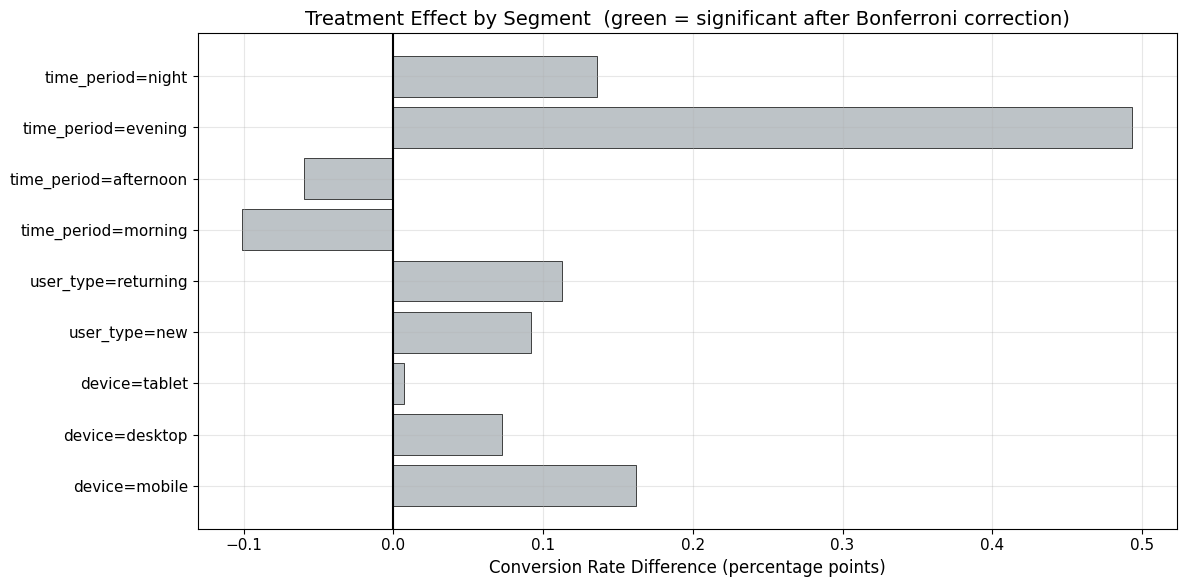

In [11]:
# Segment visualization
fig, ax = plt.subplots(figsize=(12, 6))
labels = [s["segment"] for s in segments]
diffs = [s["difference"] * 100 for s in segments]
colors = ["#27ae60" if s["significant"] else "#bdc3c7" for s in segments]
ax.barh(labels, diffs, color=colors, edgecolor="black", linewidth=0.5)
ax.axvline(x=0, color="black", linewidth=1.5)
ax.set_xlabel("Conversion Rate Difference (percentage points)")
ax.set_title("Treatment Effect by Segment  (green = significant after Bonferroni correction)")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "segment_analysis.png", dpi=150)
plt.show()


---
## Section 7: Bayesian Beta-Binomial Analysis

Instead of "is the result significant?", Bayesian analysis answers:  
**"What is the probability that treatment is better than control?"**


Posterior (Control):   Beta(18900, 131102)  — mean = 0.125998
Posterior (Treatment): Beta(19053, 130949) — mean = 0.127018

P(Treatment > Control):   0.7980 (79.8%)
Expected lift:             0.1016%
95% Credible interval:     [-0.1370%, 0.3409%]


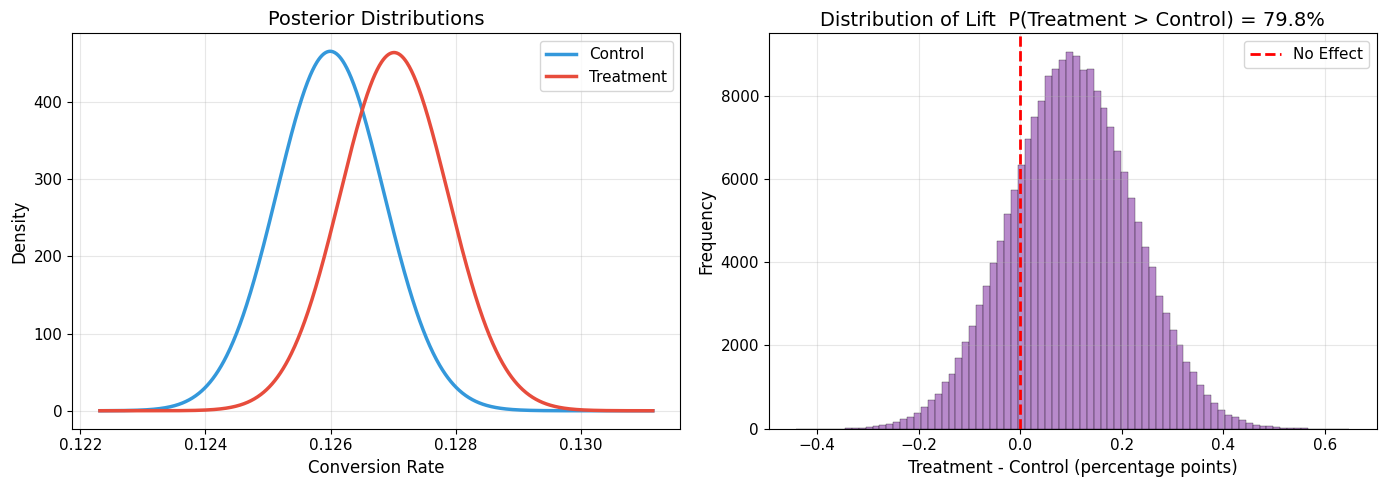

In [12]:
alpha_c = 1 + control["converted"].sum()
beta_c  = 1 + (len(control) - control["converted"].sum())
alpha_t = 1 + treatment["converted"].sum()
beta_t  = 1 + (len(treatment) - treatment["converted"].sum())

print(f"Posterior (Control):   Beta({alpha_c}, {beta_c})  — mean = {alpha_c/(alpha_c+beta_c):.6f}")
print(f"Posterior (Treatment): Beta({alpha_t}, {beta_t}) — mean = {alpha_t/(alpha_t+beta_t):.6f}")

np.random.seed(42)
samples_c = np.random.beta(alpha_c, beta_c, size=200_000)
samples_t = np.random.beta(alpha_t, beta_t, size=200_000)
prob_better = (samples_t > samples_c).mean()
expected_lift = (samples_t - samples_c).mean()
lift_ci = np.percentile(samples_t - samples_c, [2.5, 97.5])

print(f"\nP(Treatment > Control):   {prob_better:.4f} ({prob_better:.1%})")
print(f"Expected lift:             {expected_lift:.4%}")
print(f"95% Credible interval:     [{lift_ci[0]:.4%}, {lift_ci[1]:.4%}]")

# Plots
x = np.linspace(min(samples_c.min(), samples_t.min()) * 0.998,
                max(samples_c.max(), samples_t.max()) * 1.002, 1000)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(x, stats.beta.pdf(x, alpha_c, beta_c), color=COLORS["control"], linewidth=2.5, label="Control")
axes[0].plot(x, stats.beta.pdf(x, alpha_t, beta_t), color=COLORS["treatment"], linewidth=2.5, label="Treatment")
axes[0].set_xlabel("Conversion Rate")
axes[0].set_ylabel("Density")
axes[0].set_title("Posterior Distributions")
axes[0].legend()

lift_pct = (samples_t - samples_c) * 100
axes[1].hist(lift_pct, bins=80, color="#9b59b6", alpha=0.7, edgecolor="black", linewidth=0.3)
axes[1].axvline(x=0, color="red", linestyle="--", linewidth=2, label="No Effect")
axes[1].set_xlabel("Treatment - Control (percentage points)")
axes[1].set_ylabel("Frequency")
axes[1].set_title(f"Distribution of Lift  P(Treatment > Control) = {prob_better:.1%}")
axes[1].legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "bayesian_posteriors.png", dpi=150)
plt.show()


---
## Section 8: Final Recommendation


In [13]:
stat_sig = p_value < SIGNIFICANCE_LEVEL
practical_sig = abs(diff) >= PRACTICAL_THRESHOLD
adequate_power = achieved_power >= 0.80
bayes_confident = prob_better > 0.90

print("Summary of Evidence:")
print(f"  Statistically significant:   {'✅ Yes' if stat_sig else '❌ No'}")
print(f"  Practically significant:     {'✅ Yes' if practical_sig else '❌ No'}")
print(f"  Adequate statistical power:  {'✅ Yes' if adequate_power else '❌ No'}")
print(f"  Bayesian confidence (>90%):  {'✅ Yes' if bayes_confident else '❌ No'}")
print(f"  Estimated annual impact:     ${annual_revenue:+,.0f}")
print()

if stat_sig and practical_sig and adequate_power:
    rec = "SHIP"
    reason = "The new page shows a significant, practically meaningful improvement with adequate power."
elif stat_sig and not practical_sig:
    rec = "DON'T SHIP"
    reason = "Statistically significant but below practical threshold — not worth engineering effort."
elif not stat_sig and adequate_power:
    rec = "DON'T SHIP"
    reason = "Adequate power with no significant result — the new page does not improve conversion."
else:
    rec = "EXTEND THE TEST"
    reason = f"Underpowered — need ~{int(required_n):,} users/group for 80% power."

print("=" * 50)
print(f"  RECOMMENDATION: {rec}")
print("=" * 50)
print(f"  {reason}")

# Save results
results = {
    "conversion_rates": {"control": cr_control, "treatment": cr_treatment},
    "absolute_diff": diff, "relative_lift_pct": relative_lift,
    "z_statistic": z_stat, "p_value": p_value,
    "cohens_h": cohens_h, "achieved_power": achieved_power,
    "monthly_revenue_impact": monthly_revenue, "annual_revenue_impact": annual_revenue,
    "prob_treatment_better": prob_better, "expected_lift": expected_lift,
    "recommendation": rec, "segments": segments,
}
with open(RESULTS_DIR / "analysis_results.json", "w") as f:
    json.dump(results, f, indent=2, default=str)
print("\n✅ All results saved to results/analysis_results.json")


Summary of Evidence:
  Statistically significant:   ❌ No
  Practically significant:     ❌ No
  Adequate statistical power:  ❌ No
  Bayesian confidence (>90%):  ❌ No
  Estimated annual impact:     $+459,000

  RECOMMENDATION: EXTEND THE TEST
  Underpowered — need ~1,667,238 users/group for 80% power.

✅ All results saved to results/analysis_results.json
